### Author
  Lokesh Kumar Swami  
  B.Tech AI & ML (2024–2028)

#Customer medical expenses predication using linear Regression

## Problem statement 
the goal is to predict Customer medical expenses based on 
input feature using Linear Regression.

## Dataset Description
The dataset consists of input features (X) and target variable (y). 
The features represent independent variables, and the target variable represents the output to be predicted.

- X: Input features
- y: Target variable

## Import Libraries

In [31]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LinearRegression
import matplotlib.pyplot as plt

# load dataset

In [62]:
insurance_data=pd.read_csv('insurance.csv')
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# visualization of data medical expenses between smoker nad non smoker

<Axes: xlabel='bmi', ylabel='charges'>

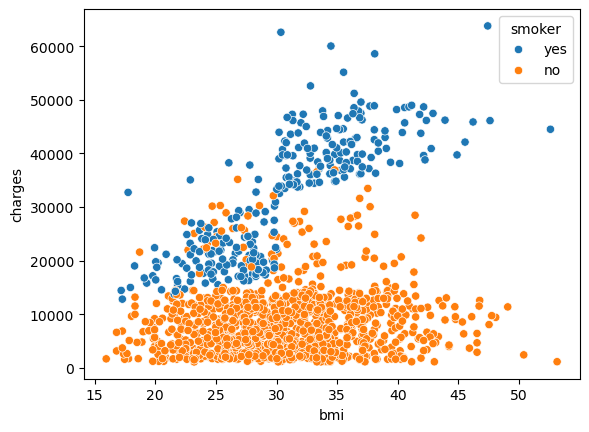

In [33]:
sns.scatterplot(x=insurance_data['bmi'],y=insurance_data['charges'],hue=insurance_data['smoker'])

# preprocessing and feature engineering

In [34]:
X=insurance_data.drop(columns=['charges','region'])

y=insurance_data['charges']
X['sex']=X['sex'].map({'female':1,'male':0})
X['smoker']=X['smoker'].map({'yes':1,'no':0})
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


## Train-Test Split
The dataset is divided into training and testing sets to evaluate the model on unseen data.

In [35]:

x_train,x_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    shuffle=True)

## Model Building
In this step, a Linear Regression model is used to learn the relationship between input features and the target variable. 
The model is trained using the training dataset.

In [36]:

model=LinearRegression()  #creating a model i.e empty now
model.fit(x_train,y_train)  #training the model means genrating the relationship 
y_pred=model.predict(x_test)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Evaluation
The performance of the model is evaluated using R² (R-squared) and Adjusted R² metrics. 
These metrics help in understanding how well the model explains the variance in the target variable.

In [38]:
#evalute the regrassion model
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
n=x_test.shape[0] #return no. of rows of dataframe i.e datapoints
p=x_test.shape[1] #return no.of columns of dataframe i.e features or input

adjusted_r2=1-((1-r2)*(n-1)/(n-p-1)) 
print(f"the adjusted_r2 value is {adjusted_r2}")

the adjusted_r2 value is 0.7769533069797342


## Visualization
The relationship between actual and predicted values is visualized using a scatter plot. 
A reference line is added to represent perfect predictions.

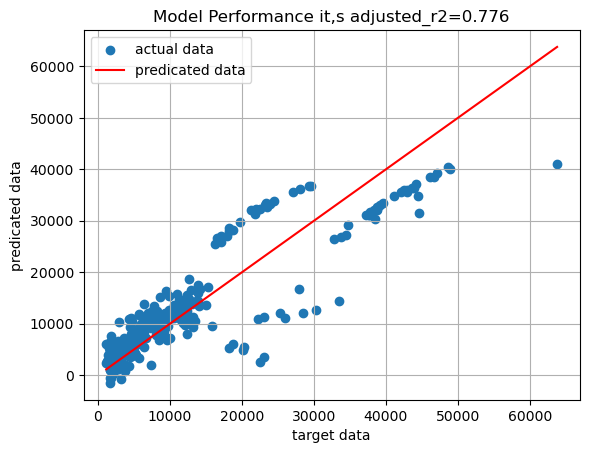

In [59]:
# Scatter plot (Actual vs Predicted)
plt.scatter(y_test, y_pred,label='actual data')

# Perfect prediction line
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(), y_test.max()],
         color='red',label='predicated data')

plt.xlabel("target data")
plt.ylabel("predicated data")
plt.title("Model Performance it,s adjusted_r2=0.776")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion
In this project, a Linear Regression model was developed to predict the target variable based on input features. 
The model was trained using training data and evaluated using R² and Adjusted R² metrics.

The results indicate that the model is able to explain a significant portion of the variance in the data, 
showing that it performs well on the given dataset.

However, the model assumes a linear relationship between variables, which may not always hold true. 
The model achieved an adjusted_R² score of 0.776953, indicating good performance.
Further improvements can be made by using more advanced models or additional features.

